# Урок 4. EDA датасета матчинга экспозиция ↔ сделки (Тюмень)

Пилот: весь город Тюмень. Данные — продакшен-БД Neolithic. Здесь только анализ данных; обучение моделей — в Уроке 5.

In [1]:
from pathlib import Path
import pandas as pd

ROOT = Path('..').resolve()
train = pd.read_parquet(ROOT / 'artifacts/datasets/tyumen_pairs_train.parquet')
holdout = pd.read_parquet(ROOT / 'artifacts/datasets/tyumen_pairs_holdout.parquet')
print('train:', train.shape, 'holdout:', holdout.shape)
print('доля positive train:', round(train['label'].mean(), 4))
print('доля positive holdout:', round(holdout['label'].mean(), 4))
train.head()

train: (46976, 31) holdout: (139422, 31)
доля positive train: 0.1672
доля positive holdout: 0.1669


,deal_id,flat_id,label,label_source,coincidence_degree,concat_fields,building_id_deal,location_id_deal,complex_id_deal,contract_date,...,room_count_exp,price_exp,is_active,area_diff,same_building,same_flat_number,same_rooms,floor_diff,price_rel_diff,contract_year
0,0000cbd2-6ae3-4777-9b01-1b9492700f04,7a6a978a-da05-4388-9069-45fef2d6bb43,1,Полное совпадение,Полное совпадение,квартира,8c1a2d84-31e3-4520-9e8c-39461660afda,b89ba893-8cc6-443c-a45c-45f8f631b325,5c7e84f3-66c6-475f-9b64-97ebd53516e9,2025-04-08,...,1.0,5120000,False,1.95,1,0,0,0.0,0.119498,2025
1,0004bb05-c9b2-4137-9276-564c2bba8a27,fde17d07-7150-4382-a127-4681fa93e9ce,1,Частичное совпадение,Частичное совпадение,площадь_за_квадратный_метр_этаж,25a2eac9-3277-47b1-b711-492883a997bb,73e6c191-eb8c-43ec-a3d3-8df14893cedb,90326714-2fd0-47f2-93f4-47e9430b8522,2025-05-22,...,4.0,18993000,False,0.00,1,0,0,0.0,0.000000,2025
2,0010f7ee-1fee-420f-8332-ba4c980fb995,4499513f-6692-4c2d-82f4-d7ce718971e9,1,Полное совпадение,Полное совпадение,квартира,84555ea0-7f5f-4dde-ae17-2ece61d39a38,140cee74-4dde-48f6-afb1-a19e8cba8158,fc2142f5-4885-4c63-ab37-c0e5db7e9649,2024-08-08,...,0.0,2790000,False,0.00,1,0,0,0.0,0.000000,2024
3,002b88f5-168d-406e-a4d9-35eebf140bdf,e06e2ac5-349e-46ac-b23b-9e307fb09a25,1,Полное совпадение,Полное совпадение,квартира,9216ff70-8927-4468-be1d-e99b55f4680c,dfc97a75-5fd4-4137-8a9e-e501b0f847d9,ff0b4d13-e5f4-4941-94ae-bdbbf37e368a,2025-06-11,...,0.0,3476559,False,0.00,1,0,0,0.0,0.032876,2025
4,003c5699-7bfb-4529-8d57-48b264fa66fb,5f6d2c12-e4a1-465d-8955-2f3db8d89aa5,1,Полное совпадение,Полное совпадение,квартира,c2b5a90d-9df9-4666-b75a-647190031731,8e40aa0c-ef93-402b-9a95-e088fc925a68,d567d9c4-e287-4f28-b5ec-7ad78144ef4f,2025-05-23,...,1.0,5358570,False,0.00,1,0,0,0.0,0.302808,2025


## EDA: объём, баланс и качество данных

пропуски по ключевым полям (train), %:
floor_diff          0.8
area_diff           0.0
same_flat_number    0.0
same_rooms          0.0
same_building       0.0
price_rel_diff      0.0
dtype: float64

Средние признаков по label:


,area_diff,floor_diff,same_flat_number,same_rooms,same_building,price_rel_diff
label,,,,,,
0,18.617,5.271,0.0,0.002,1.000,0.298
1,0.769,0.776,0.0,0.003,0.937,0.091


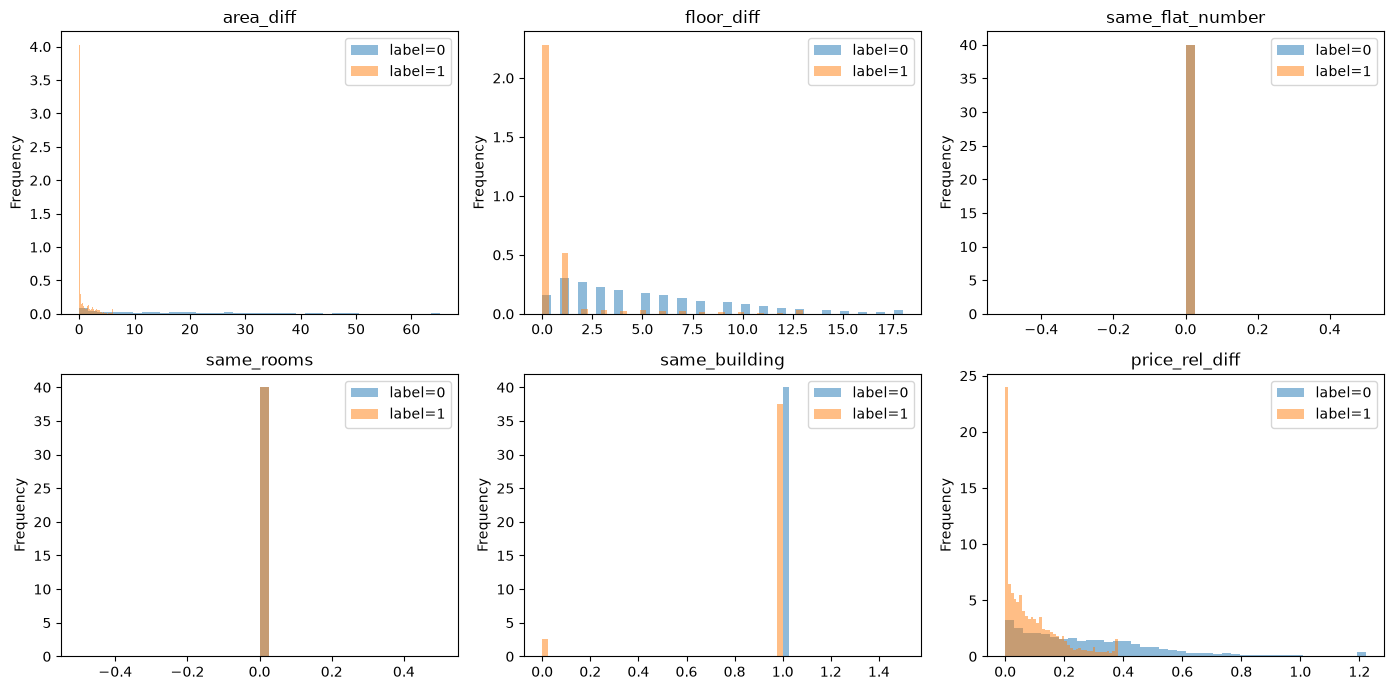

Выводы:
- Сильный дисбаланс (~1:5) → PR-AUC/F1 важнее accuracy; нужен subsample/class_weight.
- same_building/same_flat_number резко разделяют классы (блокирующие ключи).
- area_diff/floor_diff у positives ближе к 0, но хвосты шумные → не exact match.
- price_rel_diff — вспомогательный признак, не ключ.


In [2]:
import matplotlib.pyplot as plt

cols = ['area_diff','floor_diff','same_flat_number','same_rooms','same_building','price_rel_diff']

# 1) Пропуски по ключевым полям
print('пропуски по ключевым полям (train), %:')
print((train[cols].isna().mean() * 100).round(1).sort_values(ascending=False))

# 2) Средние по классам
print('\nСредние признаков по label:')
display(train.groupby('label')[cols].mean().round(3))

# 3) Распределения
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.ravel(), cols):
    for lab, g in train.groupby('label'):
        g[c].dropna().clip(upper=g[c].quantile(0.99)).plot.hist(
            bins=40, alpha=0.5, density=True, ax=ax, label=f'label={lab}')
    ax.set_title(c)
    ax.legend()
plt.tight_layout()
plt.show()

# 4) Выводы
print('Выводы:')
print('- Сильный дисбаланс (~1:5) → PR-AUC/F1 важнее accuracy; нужен subsample/class_weight.')
print('- same_building/same_flat_number резко разделяют классы (блокирующие ключи).')
print('- area_diff/floor_diff у positives ближе к 0, но хвосты шумные → не exact match.')
print('- price_rel_diff — вспомогательный признак, не ключ.')

## Выводы для моделирования

1. Сильный дисбаланс классов (~1:5) — метрики PR-AUC/F1, subsample или class_weight.
2. `same_building`, `same_flat_number` — сильные блокирующие ключи.
3. `area_diff`, `floor_diff` информативны, но с шумом — точное равенство редко.
4. `price_rel_diff` — вспомогательный признак.
5. Weak labels из rule-сцепки шумные — нужен экспертный gold-set для финальной оценки.

Подробности стратегии данных: `EDA/dataset.md`. Обучение baseline — `notebooks/lesson6_baseline.ipynb` (Урок 5).